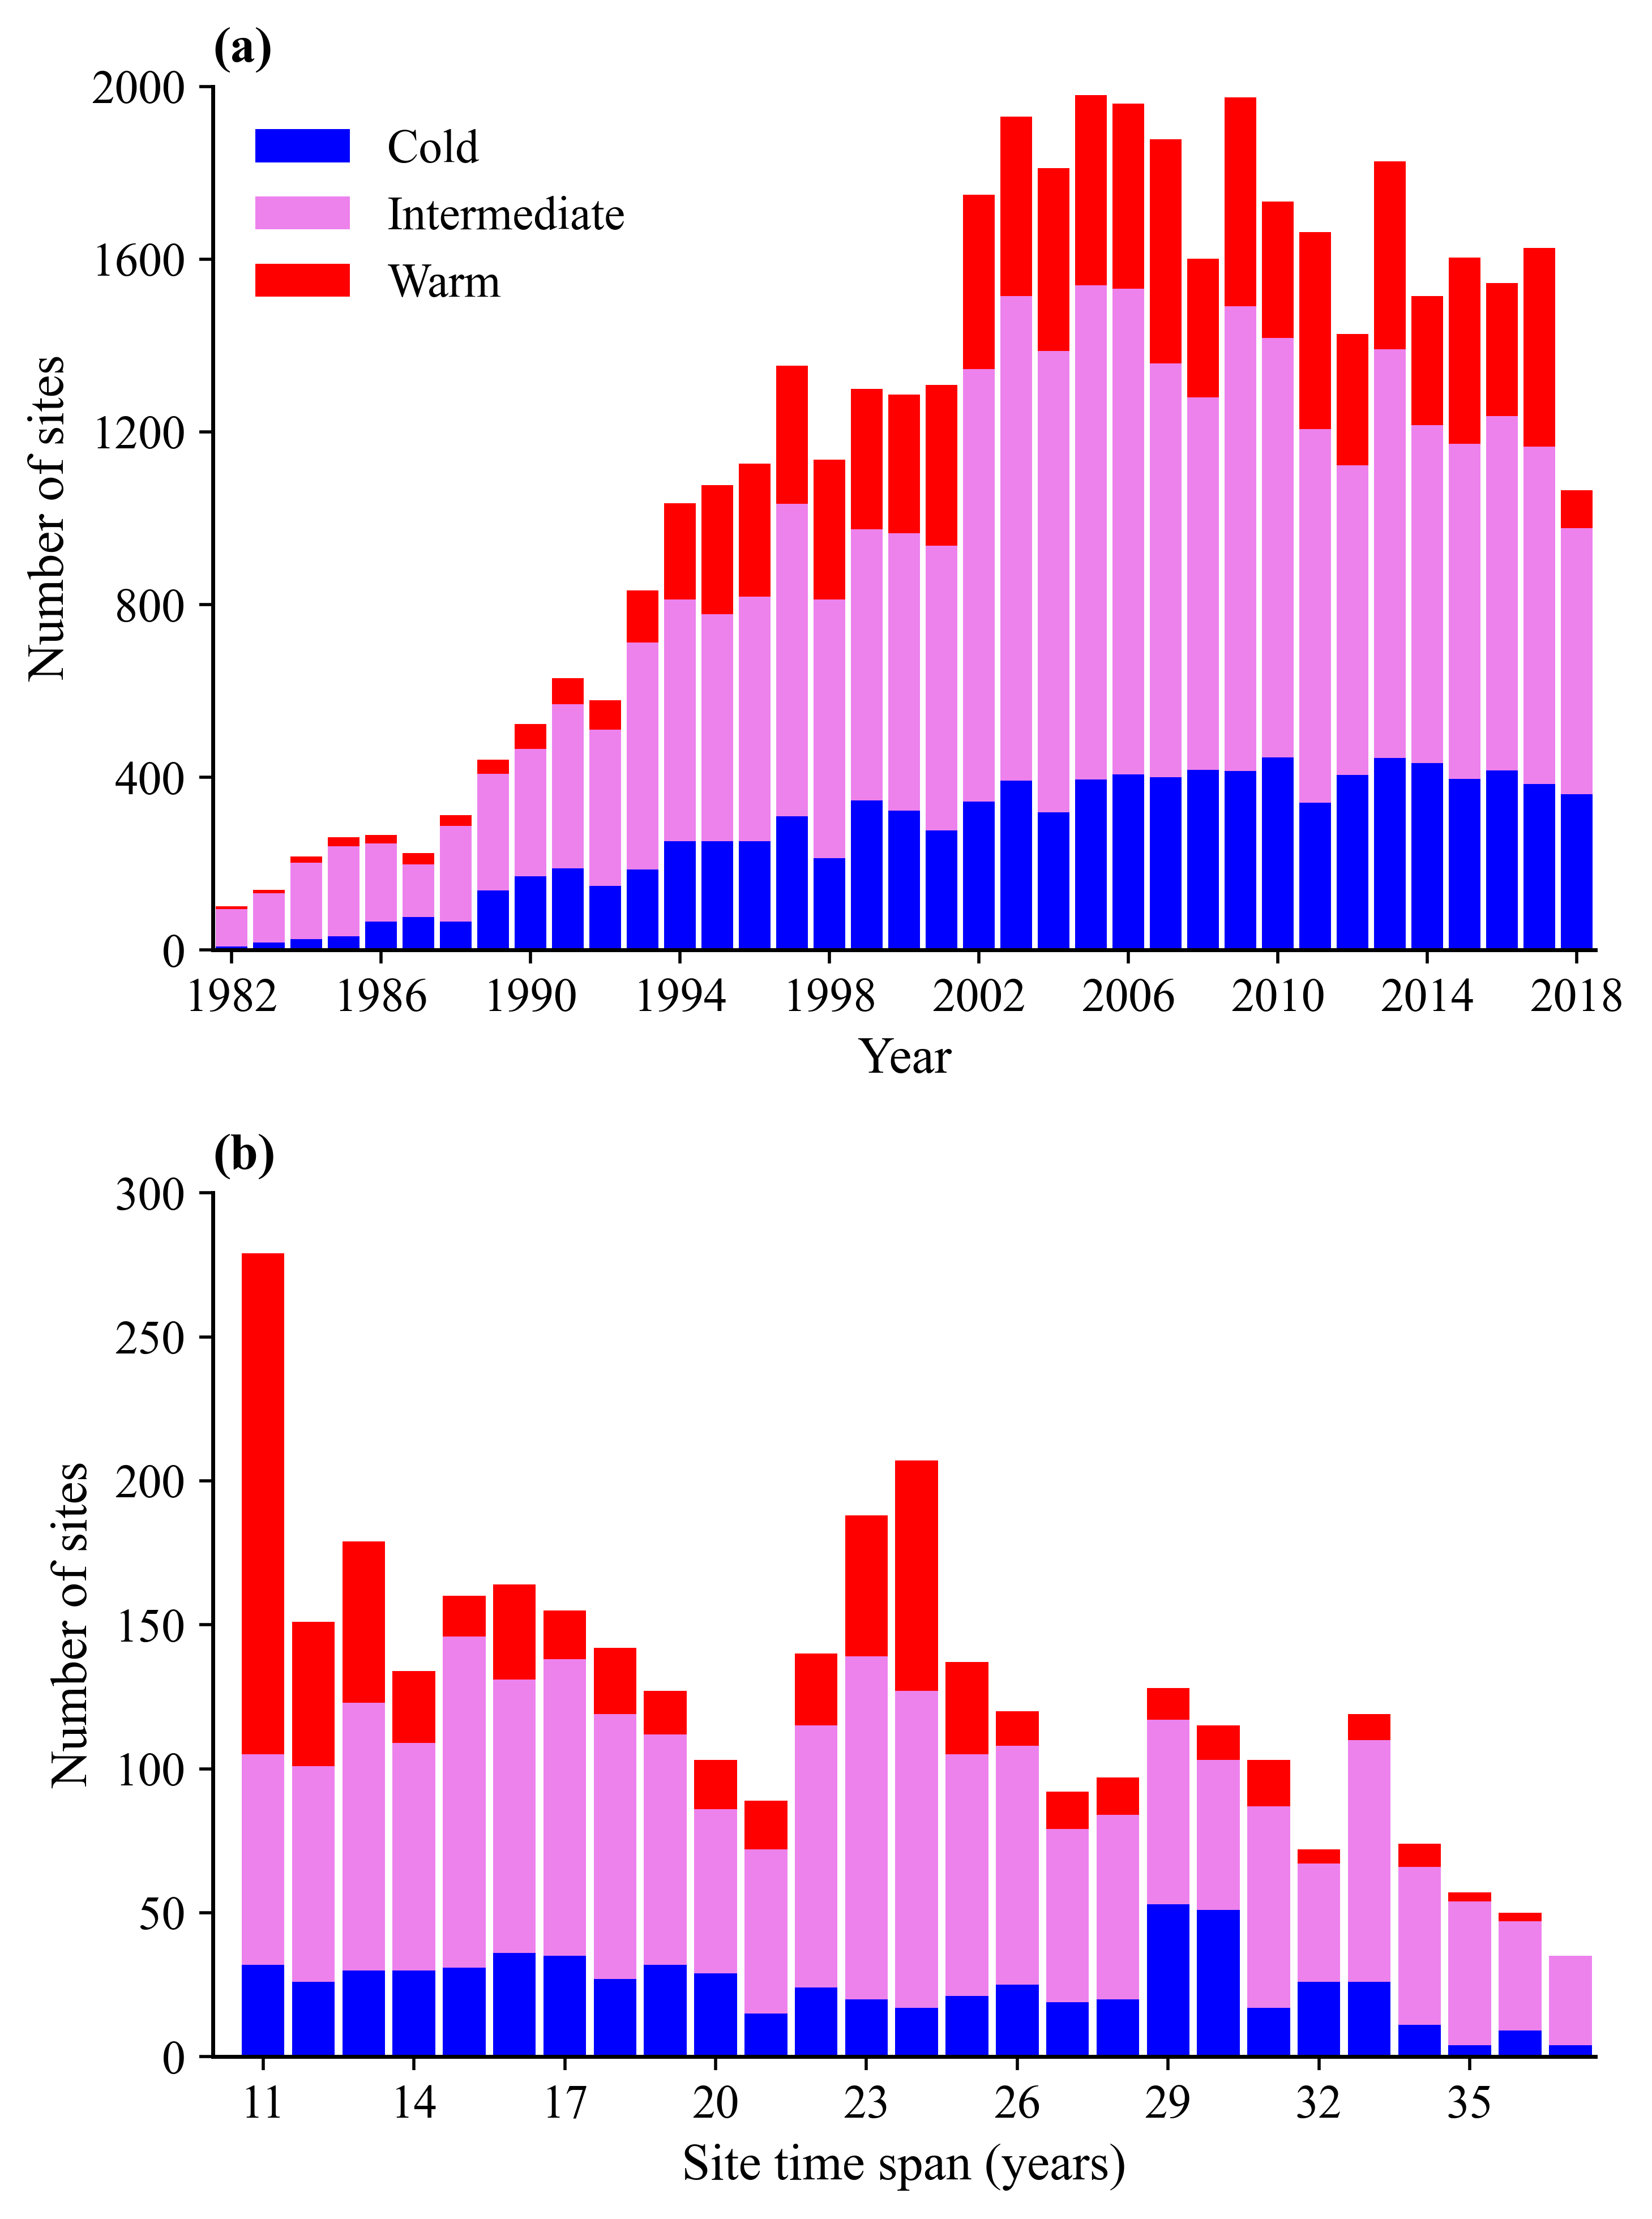

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "Times New Roman",
    "axes.linewidth": 1,
    "font.size": 12
})

file = r"D:\NC\Data\rivernet\inputdata\richness.csv"
df = pd.read_csv(file)

df = df[["SiteID", "year", "zone"]].dropna()

zones_order = ["Cold", "Intermediate", "Warm"]
df = df[df["zone"].isin(zones_order)].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)
years = np.sort(df["year"].unique())

sites_df = (
    df.groupby(["year", "zone"])["SiteID"]
      .nunique()
      .reset_index(name="n_sites")
)

sites_wide = (
    sites_df
    .pivot(index="year", columns="zone", values="n_sites")
    .fillna(0)
    .astype(int)
)[zones_order]
site_span = (
    df.groupby(["SiteID", "zone"])["year"]
      .agg(start_year="min", end_year="max")
      .reset_index()
)

site_span["span_years"] = site_span["end_year"] - site_span["start_year"] + 1
site_span = site_span[site_span["span_years"] > 0]

max_span = int(site_span["span_years"].max())
span_bins = np.arange(1, max_span + 1)

span_count = (
    site_span
    .groupby(["span_years", "zone"])
    .size()
    .reset_index(name="n_sites")
)

span_wide = (
    span_count
    .pivot(index="span_years", columns="zone", values="n_sites")
    .fillna(0)
    .astype(int)
    .reindex(span_bins, fill_value=0)
)[zones_order]

fig, axes = plt.subplots(
    2, 1,
    figsize=(6, 8),
    dpi=500
)

colors = {
    "Cold": "#0000ff",
    "Intermediate": "#ed82ed",
    "Warm": "#ff0000"
}

ax = axes[0]
bottom = np.zeros(len(sites_wide))

for zone in zones_order:
    ax.bar(
        years,
        sites_wide[zone].values,
        bottom=bottom,
        width=0.85,
        color=colors[zone],
        label=zone
    )
    bottom += sites_wide[zone].values

ax.set_ylabel("Number of sites", fontsize=13)
ax.set_xlabel("Year", fontsize=13)
ax.set_title("(a)", loc="left", fontsize=13, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(0, 2000)
ax.set_yticks(np.arange(0, 2001, 400))
ax.set_xlim(years.min() - 0.5, years.max() + 0.5)
ax.set_xticks(np.arange(years.min(), years.max() + 1, 4))
ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper left"
)


ax = axes[1]
x = span_wide.index.values
bottom = np.zeros(len(span_wide))

for zone in zones_order:
    ax.bar(
        x,
        span_wide[zone].values,
        bottom=bottom,
        width=0.85,
        color=colors[zone]
    )
    bottom += span_wide[zone].values

ax.set_ylabel("Number of sites", fontsize=13)
ax.set_xlabel("Site time span (years)", fontsize=13)
ax.set_title("(b)", loc="left", fontsize=13, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(10,37.5)
ax.set_xticks(np.arange(11, 38, 3))
ax.set_ylim(0, 300)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Lenovo\Desktop\extendFig1.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()